# 03 - Hourly Aggregation

## Electricity Consumption Analysis and Short-Term Demand Forecasting

### Objective

The cleaned dataset contains minute-level electricity measurements. Working directly with more than two million minute-level observations is unnecessary for our college project.

In this notebook, we will convert the cleaned minute-level data into an **hourly electricity-consumption dataset**.

### Why hourly aggregation?

Hourly data is useful because it:

- reduces the dataset size substantially,
- makes daily and weekly patterns easier to analyze,
- is easier to visualize,
- reduces high-frequency noise,
- provides a practical time resolution for short-term demand forecasting.

The cleaned minute-level dataset will remain unchanged. We will create a separate hourly dataset.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load the Cleaned Dataset

The cleaned dataset was created in `02_data_cleaning.ipynb` and stored in the `data/processed/` folder.


In [2]:
file_path = "../data/processed/cleaned_household_power_consumption.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["DateTime"]
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1474985, 8)


,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 3. Inspect the Cleaned Data


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1474985 entries, 0 to 1474984
Data columns (total 8 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   DateTime               1474985 non-null  datetime64[us]
 1   Global_active_power    1474985 non-null  float64       
 2   Global_reactive_power  1474985 non-null  float64       
 3   Voltage                1474985 non-null  float64       
 4   Global_intensity       1474985 non-null  float64       
 5   Sub_metering_1         1474985 non-null  float64       
 6   Sub_metering_2         1474985 non-null  float64       
 7   Sub_metering_3         1474985 non-null  float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 90.0 MB


## 4. Set DateTime as the Index

Time-series aggregation in Pandas is easier when the datetime column is used as the DataFrame index.


In [4]:
df = df.set_index("DateTime").sort_index()

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 5. Check the Time Coverage

Inspect the first and last timestamps and confirm the time span of the cleaned dataset.


In [5]:
print("Start:", df.index.min())
print("End:", df.index.max())
print("Number of observations:", len(df))

Start: 2006-12-16 17:24:00
End: 2009-10-06 00:28:00
Number of observations: 1474985


## 6. Aggregate Minute-Level Data to Hourly Data

The primary target for our project is `Global_active_power`.

For each hour, we calculate the **mean** of the minute-level measurements.

The mean is appropriate here because we want the typical power level during each hour.

We also aggregate the other electrical measurements so that the resulting hourly dataset retains useful information for later analysis.


In [6]:
hourly_df = df.resample("h").mean()

hourly_df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## 7. Inspect the Hourly Dataset Dimensions


In [7]:
print("Hourly dataset shape:", hourly_df.shape)


Hourly dataset shape: (24584, 7)


## 8. Check Missing Values After Aggregation

Aggregation can create empty hourly periods when no original observations are available for a particular hour.

We check for missing values before deciding how to handle them.


In [8]:
hourly_missing = hourly_df.isnull().sum()

hourly_missing


Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

## 9. Check Missing Hours

Count how many hourly rows contain at least one missing measurement.


In [9]:
missing_hours = hourly_df.isnull().any(axis=1).sum()

print("Hours with at least one missing value:", missing_hours)
print("Total hourly observations:", len(hourly_df))


Hours with at least one missing value: 0
Total hourly observations: 24584


## 10. Handle Missing Hourly Values

For the forecasting dataset, we need a continuous hourly time series.

We use time-based interpolation to estimate missing hourly measurements from neighboring observations.

As with the minute-level cleaning stage, we do **not** replace missing electricity measurements with zero.


In [10]:
hourly_df = hourly_df.interpolate(
    method="time",
    limit_direction="both"
)

print("Remaining missing values:", hourly_df.isnull().sum().sum())


Remaining missing values: 0


## 11. Rename the Main Target Variable

For readability, rename `Global_active_power` to `Electricity_Consumption`.

This variable will be the main target for our exploratory analysis and forecasting models.


In [11]:
hourly_df = hourly_df.rename(
    columns={"Global_active_power": "Electricity_Consumption"}
)

hourly_df.head()


,Electricity_Consumption,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## 12. Add Calendar Features

Calendar features will help us analyze consumption patterns.

We create:

- Year
- Month
- Day
- Hour
- Day of Week
- Weekend indicator
- Quarter


In [12]:
hourly_df["Year"] = hourly_df.index.year
hourly_df["Month"] = hourly_df.index.month
hourly_df["Day"] = hourly_df.index.day
hourly_df["Hour"] = hourly_df.index.hour
hourly_df["DayOfWeek"] = hourly_df.index.dayofweek
hourly_df["IsWeekend"] = (hourly_df["DayOfWeek"] >= 5).astype(int)
hourly_df["Quarter"] = hourly_df.index.quarter

hourly_df.head()


,Electricity_Consumption,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Quarter
DateTime,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,2006,12,16,17,5,1,4
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,2006,12,16,18,5,1,4
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,2006,12,16,19,5,1,4
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,2006,12,16,20,5,1,4
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,2006,12,16,21,5,1,4


## 13. Create a Readable Day-of-Week Column

The numerical `DayOfWeek` column is useful for machine learning, while the text label is useful for charts and interpretation.


In [13]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

hourly_df["DayName"] = hourly_df["DayOfWeek"].map(day_names)

hourly_df[["Electricity_Consumption", "Hour", "DayOfWeek", "DayName", "IsWeekend"]].head()


,Electricity_Consumption,Hour,DayOfWeek,DayName,IsWeekend
DateTime,,,,,
2006-12-16 17:00:00,4.222889,17,5,Saturday,1
2006-12-16 18:00:00,3.632200,18,5,Saturday,1
2006-12-16 19:00:00,3.400233,19,5,Saturday,1
2006-12-16 20:00:00,3.268567,20,5,Saturday,1
2006-12-16 21:00:00,3.056467,21,5,Saturday,1


## 14. Basic Hourly Consumption Statistics


In [14]:
hourly_df["Electricity_Consumption"].describe()


count    24584.000000
mean         1.083457
std          0.925465
min          0.124000
25%          0.323125
50%          0.761883
75%          1.574867
max          6.560533
Name: Electricity_Consumption, dtype: float64

## 15. Inspect Hourly Consumption Trend

Create a simple visualization to confirm that the hourly aggregation has produced a meaningful time series.


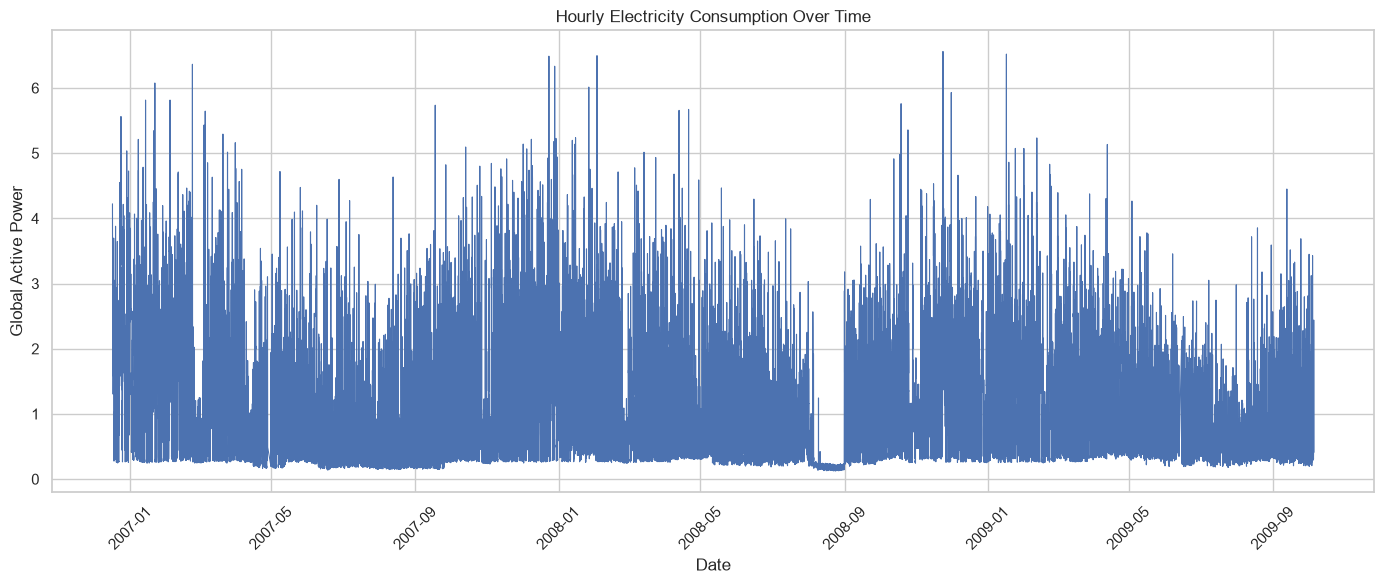

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    hourly_df.index,
    hourly_df["Electricity_Consumption"],
    linewidth=0.8
)

plt.title("Hourly Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 16. Check Average Consumption by Hour

This gives an early view of the daily electricity-demand pattern.


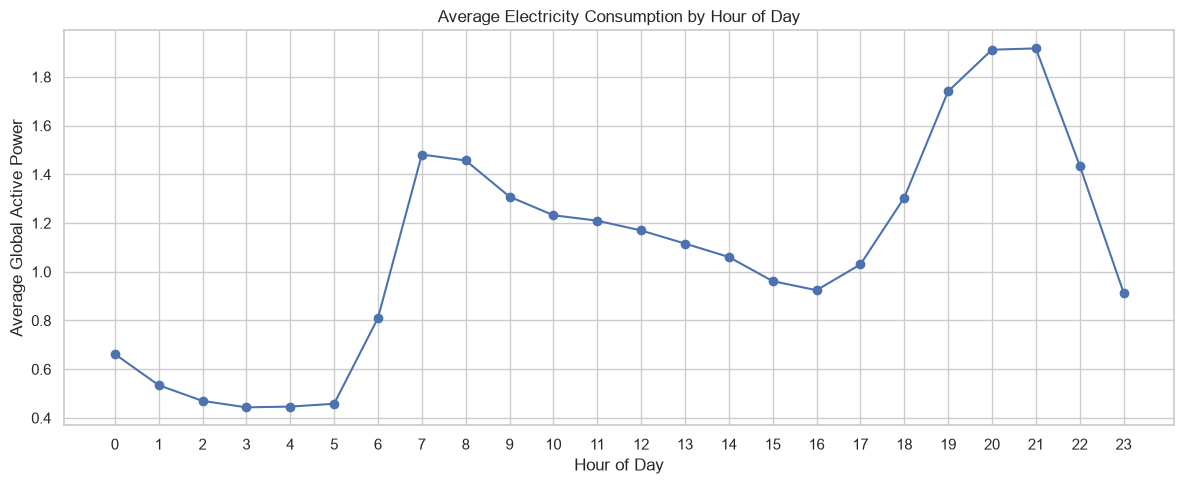

In [16]:
hourly_pattern = (
    hourly_df.groupby("Hour")["Electricity_Consumption"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Electricity Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


## 17. Save the Hourly Dataset

Save the processed hourly dataset so that the next notebooks do not need to repeat the aggregation step.


In [17]:
output_path = "../data/processed/hourly_electricity_consumption.csv"

hourly_df.to_csv(output_path, index_label="DateTime")

print("Hourly dataset saved to:")
print(output_path)


Hourly dataset saved to:
../data/processed/hourly_electricity_consumption.csv


## 18. Final Validation

Check the final structure before moving to exploratory data analysis.


In [18]:
print("Final hourly dataset shape:", hourly_df.shape)
print("Start:", hourly_df.index.min())
print("End:", hourly_df.index.max())
print("Remaining missing values:", hourly_df.isnull().sum().sum())

print("\nColumns:")
print(hourly_df.columns.tolist())

Final hourly dataset shape: (24584, 15)
Start: 2006-12-16 17:00:00
End: 2009-10-06 00:00:00
Remaining missing values: 0

Columns:
['Electricity_Consumption', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'IsWeekend', 'Quarter', 'DayName']


## Conclusion

The minute-level electricity data has been converted into a clean hourly dataset.

### Completed tasks

- Loaded the cleaned minute-level dataset.
- Converted `DateTime` to the time-series index.
- Aggregated minute-level measurements into hourly averages.
- Checked for missing hourly periods.
- Applied time-based interpolation where required.
- Created calendar features.
- Created a readable day-of-week feature.
- Examined the initial hourly consumption pattern.
- Saved the hourly dataset.

### Next notebook

**04 - Exploratory Data Analysis**

In the next stage, we will investigate:

- overall electricity-consumption trends,
- hourly patterns,
- daily patterns,
- monthly and seasonal patterns,
- weekday versus weekend consumption,
- peak-demand periods,
- consumption distributions,
- relationships between electrical variables,
- and unusual consumption periods.
